In [1]:
# Pressure Drop Detection and Storm-Risk Expert System
import os
import json
import requests

from datetime import datetime

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window

import matplotlib.pyplot as plt

# Spark Session

spark = SparkSession.builder.appName("Storm Risk Expert System").getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Storm Risk Expert System")

print(f"Spark version : {spark.version}")
print()

# API Config

TOKEN = "STUDENT_TOKEN_2026"

BASE_URL = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev"

HEADERS = {
    "Authorization": f"Bearer {TOKEN}"
}

STATION_ID = "GDN_01"

LIMIT = 100

# Folders

os.makedirs("raw_data", exist_ok=True)
os.makedirs("processed", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Folders ready.")
print("Project initialized.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/29 12:52:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Storm Risk Expert System
Spark version : 4.0.3

Folders ready.
Project initialized.


In [3]:
#Download Weather Data from REST API

print("Downloading weather data...")

response = requests.get(
    f"{BASE_URL}/weather/batch",
    headers=HEADERS,
    params={
        "station_id": STATION_ID,
        "limit": LIMIT
    }
)

response.raise_for_status()

data = response.json()

raw_file = f"raw_data/weather_raw_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

with open(raw_file, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print("Download completed.")
print(f"Raw file saved:\n{raw_file}")

# Preview API response
print("\nResponse type:", type(data))

if isinstance(data, list):
    print("Number of elements:", len(data))

elif isinstance(data, dict):
    print("Keys:", list(data.keys()))

Download completed.
Raw file saved:
raw_data/weather_raw_20260629_092939.json

Response type: <class 'dict'>
Keys: ['station_id', 'count', 'records']


In [4]:
import pandas as pd

pdf = pd.DataFrame(data["records"])

spark_df = spark.createDataFrame(pdf)

print("\nSchema")

spark_df.printSchema()

print("\nFirst rows")

spark_df.show(5, truncate=False)

print("\nNumber of records:", spark_df.count())


Schema
root
 |-- timestamp: string (nullable = true)
 |-- station_id: string (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- wind_direction: long (nullable = true)
 |-- rain_mm: double (nullable = true)
 |-- cloud_cover: long (nullable = true)


First rows


+--------------------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|timestamp                       |station_id|temperature|humidity|pressure|wind_speed|wind_direction|rain_mm|cloud_cover|
+--------------------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|2026-06-29T09:29:39.067318+00:00|GDN_01    |14.17      |67.3    |1011.29 |12.68     |11            |2.53   |58         |
|2026-06-29T09:19:39.067318+00:00|GDN_01    |15.9       |54.35   |1007.36 |6.46      |222           |3.27   |47         |
|2026-06-29T09:09:39.067318+00:00|GDN_01    |18.45      |58.87   |1012.49 |4.99      |135           |1.06   |45         |
|2026-06-29T08:59:39.067318+00:00|GDN_01    |16.97      |93.7    |1022.12 |13.82     |143           |0.0    |31         |
|2026-06-29T08:49:39.067318+00:00|GDN_01    |17.75      |63.19   |1006.01 |1.5       |224           |1.79   |42         |
+-----------------------

In [5]:
#Data Validation and Cleaning

print("DATA VALIDATION")

# Remove duplicated rows
spark_df = spark_df.dropDuplicates()

# Remove rows with NULL values in important columns
required_columns = [
    "timestamp",
    "pressure",
    "wind_speed",
    "rain_mm",
    "cloud_cover"
]

spark_df = spark_df.dropna(subset=required_columns)

# Convert timestamp

spark_df = spark_df.withColumn(
    "timestamp",
    to_timestamp(col("timestamp"))
)

# Remove rows with invalid timestamp

spark_df = spark_df.filter(col("timestamp").isNotNull())

print("Records after validation:", spark_df.count())

spark_df.show(5)

DATA VALIDATION
Records after validation: 100
+--------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|           timestamp|station_id|temperature|humidity|pressure|wind_speed|wind_direction|rain_mm|cloud_cover|
+--------------------+----------+-----------+--------+--------+----------+--------------+-------+-----------+
|2026-06-29 08:49:...|    GDN_01|      17.75|   63.19| 1006.01|       1.5|           224|   1.79|         42|
|2026-06-29 07:49:...|    GDN_01|      17.62|   46.27| 1026.05|      4.61|           296|   1.42|         63|
|2026-06-29 06:29:...|    GDN_01|      20.81|   53.32| 1010.49|      4.61|            47|    0.0|         58|
|2026-06-29 08:19:...|    GDN_01|      13.14|   73.72| 1003.28|      9.58|           145|    0.0|         36|
|2026-06-29 08:59:...|    GDN_01|      16.97|    93.7| 1022.12|     13.82|           143|    0.0|         31|
+--------------------+----------+-----------+--------+--------+----------+

In [6]:
#Pressure Trend Analysis

print("PRESSURE ANALYSIS")

window = Window.orderBy("timestamp")

spark_df = spark_df.withColumn(
    "pressure_delta",
    col("pressure") - lag("pressure").over(window)
)

rolling_window = Window.orderBy("timestamp").rowsBetween(-4, 0)

spark_df = spark_df.withColumn(
    "pressure_rolling",
    avg("pressure").over(rolling_window)
)

spark_df.select(
    "timestamp",
    "pressure",
    "pressure_delta",
    "pressure_rolling"
).show(10, truncate=False)

PRESSURE ANALYSIS
+--------------------------+--------+-------------------+------------------+
|timestamp                 |pressure|pressure_delta     |pressure_rolling  |
+--------------------------+--------+-------------------+------------------+
|2026-06-28 16:59:39.067318|1014.4  |NULL               |1014.4            |
|2026-06-28 17:09:39.067318|998.79  |-15.610000000000014|1006.595          |
|2026-06-28 17:19:39.067318|1000.36 |1.57000000000005   |1004.5166666666668|
|2026-06-28 17:29:39.067318|1019.3  |18.93999999999994  |1008.2125000000001|
|2026-06-28 17:39:39.067318|1019.79 |0.4900000000000091 |1010.528          |
|2026-06-28 17:49:39.067318|1005.97 |-13.819999999999936|1008.842          |
|2026-06-28 17:59:39.067318|1000.72 |-5.25              |1009.2280000000001|
|2026-06-28 18:09:39.067318|1003.87 |3.1499999999999773 |1009.93           |
|2026-06-28 18:19:39.067318|1027.35 |23.479999999999905 |1011.54           |
|2026-06-28 18:29:39.067318|1028.26 |0.9100000000000819 |1

In [7]:
#Expert System

print("EXPERT SYSTEM")

spark_df = spark_df.withColumn("score", lit(0))

# Pressure
# Larger pressure drops may indicate unstable weather.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("pressure_delta") <= -10, 3)
    .when(col("pressure_delta") <= -5, 2)
    .when(col("pressure_delta") <= -2, 1)
    .otherwise(0)
)

# Pressure below rolling average
# A pressure value lower than the recent rolling average may indicate an approaching low-pressure system.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("pressure") < col("pressure_rolling") - 3, 2)
    .when(col("pressure") < col("pressure_rolling") - 1, 1)
    .otherwise(0)
)

# Wind
# Strong wind may be associated with weather fronts.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("wind_speed") >= 12, 3)
    .when(col("wind_speed") >= 8, 2)
    .when(col("wind_speed") >= 5, 1)
    .otherwise(0)
)

# Rain
# Rain may indicate big rain clouds

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("rain_mm") >= 2, 3)
    .when(col("rain_mm") >= 1, 2)
    .when(col("rain_mm") > 0, 1)
    .otherwise(0)
)

# Clouds
# High cloud cover may be a sign of unstable weather.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(col("cloud_cover") >= 90, 3)
    .when(col("cloud_cover") >= 70, 2)
    .when(col("cloud_cover") >= 50, 1)
    .otherwise(0)
)

# More advanced calculation rules

# Rapid pressure drop together with strong wind increases the probability of storm development.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("pressure_delta") <= -5) &
        (col("wind_speed") >= 8),
        2
    ).otherwise(0)
)

# Pressure drop and rainfall indicate an active weather front.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("pressure_delta") <= -5) &
        (col("rain_mm") > 0),
        1
    ).otherwise(0)
)

# Dense cloud cover together with strong wind suggests unstable conditions.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("cloud_cover") >= 90) &
        (col("wind_speed") >= 10),
        2
    ).otherwise(0)
)

# If all major indicators together, increase the confidance of storm detection.

spark_df = spark_df.withColumn(
    "score",
    col("score") +
    when(
        (col("pressure_delta") <= -5) &
        (col("wind_speed") >= 8) &
        (col("cloud_cover") >= 90) &
        (col("rain_mm") > 0),
        3
    ).otherwise(0)
)

# Classification

spark_df = spark_df.withColumn(
    "storm_risk",
    when(col("score") >= 11, "HIGH")
    .when(col("score") >= 6, "MEDIUM")
    .otherwise("LOW")
)

spark_df.select(
    "timestamp",
    "pressure",
    "pressure_delta",
    "wind_speed",
    "rain_mm",
    "cloud_cover",
    "score",
    "storm_risk"
).show(20, truncate=False)

EXPERT SYSTEM
+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|timestamp                 |pressure|pressure_delta     |wind_speed|rain_mm|cloud_cover|score|storm_risk|
+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|2026-06-28 16:59:39.067318|1014.4  |NULL               |3.04      |0.0    |70         |2    |LOW       |
|2026-06-28 17:09:39.067318|998.79  |-15.610000000000014|8.21      |0.0    |44         |9    |MEDIUM    |
|2026-06-28 17:19:39.067318|1000.36 |1.57000000000005   |1.8       |1.09   |10         |4    |LOW       |
|2026-06-28 17:29:39.067318|1019.3  |18.93999999999994  |2.88      |1.23   |81         |4    |LOW       |
|2026-06-28 17:39:39.067318|1019.79 |0.4900000000000091 |10.6      |0.0    |91         |7    |MEDIUM    |
|2026-06-28 17:49:39.067318|1005.97 |-13.819999999999936|4.63      |0.61   |99         |9    |MEDIUM    |
|2026-06-28 17:59:39.067318|1000

In [8]:
# Alert Log

from pyspark.sql.functions import current_timestamp, monotonically_increasing_id

print("ALERT LOG")

alerts = (
    spark_df
    .filter(col("storm_risk") == "HIGH")
    .withColumn("alert_id", monotonically_increasing_id() + 1)
    .withColumn("generated_at", current_timestamp())
)

print(f"Number of HIGH alerts: {alerts.count()}")

alerts.select(
    "alert_id",
    "generated_at",
    "timestamp",
    "pressure",
    "pressure_delta",
    "wind_speed",
    "rain_mm",
    "cloud_cover",
    "score",
    "storm_risk"
).show(truncate=False)

ALERT LOG
Number of HIGH alerts: 12
+--------+--------------------------+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|alert_id|generated_at              |timestamp                 |pressure|pressure_delta     |wind_speed|rain_mm|cloud_cover|score|storm_risk|
+--------+--------------------------+--------------------------+--------+-------------------+----------+-------+-----------+-----+----------+
|1       |2026-06-29 09:29:51.772601|2026-06-28 18:39:39.067318|996.33  |-31.92999999999995 |12.45     |0.0    |65         |11   |HIGH      |
|2       |2026-06-29 09:29:51.772601|2026-06-28 18:49:39.067318|1021.11 |24.779999999999973 |13.4      |2.62   |96         |11   |HIGH      |
|3       |2026-06-29 09:29:51.772601|2026-06-28 19:49:39.067318|1003.23 |-21.279999999999973|11.96     |0.86   |12         |11   |HIGH      |
|4       |2026-06-29 09:29:51.772601|2026-06-28 20:19:39.067318|1005.27 |-19.410000000000082|12.19     |0.0    |

In [9]:
#Save Results

spark_df.write.mode("overwrite").parquet("processed/weather_curated.parquet")

spark_df.coalesce(1).write.mode("overwrite").option("header",True).csv("processed/weather_processed_csv")

alerts.coalesce(1).write.mode("overwrite").option("header",True).csv("processed/storm_alerts_csv")

print("Files saved successfully.")

Files saved successfully.


In [10]:
#Statistics

print("PROJECT STATISTICS")

print("Number of measurements:", spark_df.count())

spark_df.groupBy("storm_risk").count().show()

print("Number of HIGH alerts:", alerts.count())

PROJECT STATISTICS
Number of measurements: 100
+----------+-----+
|storm_risk|count|
+----------+-----+
|       LOW|   53|
|    MEDIUM|   35|
|      HIGH|   12|
+----------+-----+

Number of HIGH alerts: 12


In [11]:
#High Risk Case

print("HIGHEST RISK SINGLE CASE")

case = spark_df.orderBy(col("score").desc())

case.select(
    "timestamp",
    "pressure",
    "pressure_delta",
    "pressure_rolling",
    "wind_speed",
    "rain_mm",
    "cloud_cover",
    "score",
    "storm_risk"
).show(1, truncate=False)

HIGHEST RISK SINGLE CASE
+--------------------------+--------+-------------------+------------------+----------+-------+-----------+-----+----------+
|timestamp                 |pressure|pressure_delta     |pressure_rolling  |wind_speed|rain_mm|cloud_cover|score|storm_risk|
+--------------------------+--------+-------------------+------------------+----------+-------+-----------+-----+----------+
|2026-06-29 05:39:39.067318|1009.57 |-15.409999999999968|1016.7940000000001|9.13      |0.86   |98         |17   |HIGH      |
+--------------------------+--------+-------------------+------------------+----------+-------+-----------+-----+----------+
only showing top 1 row


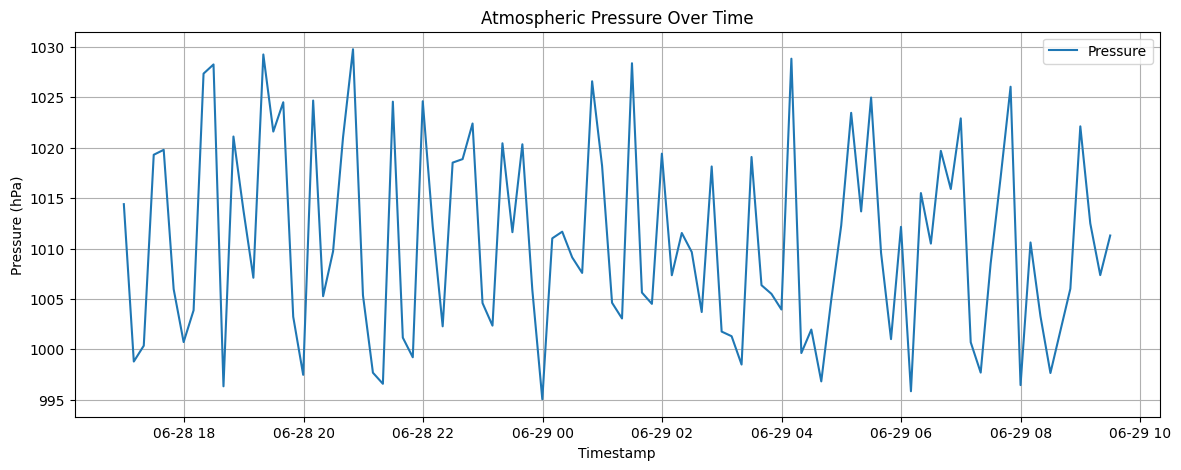

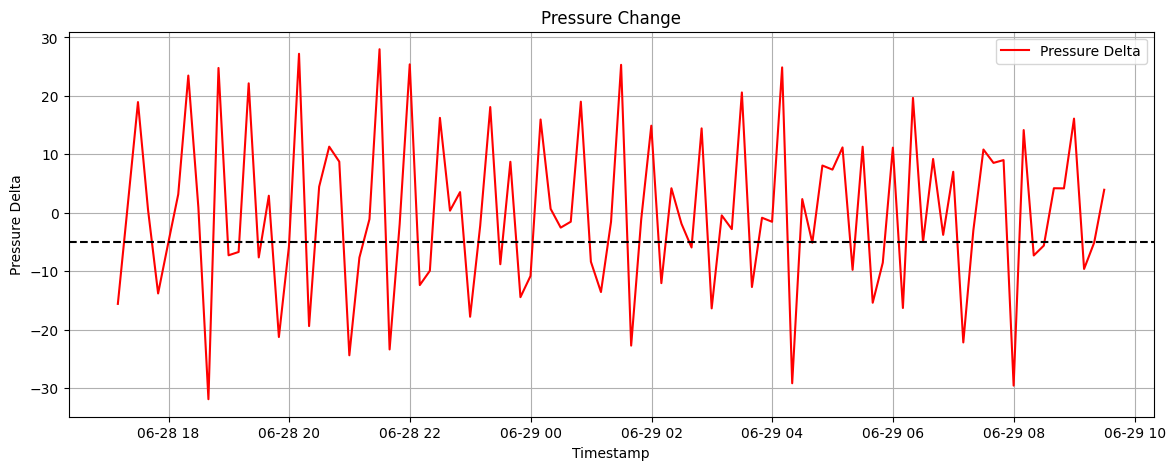

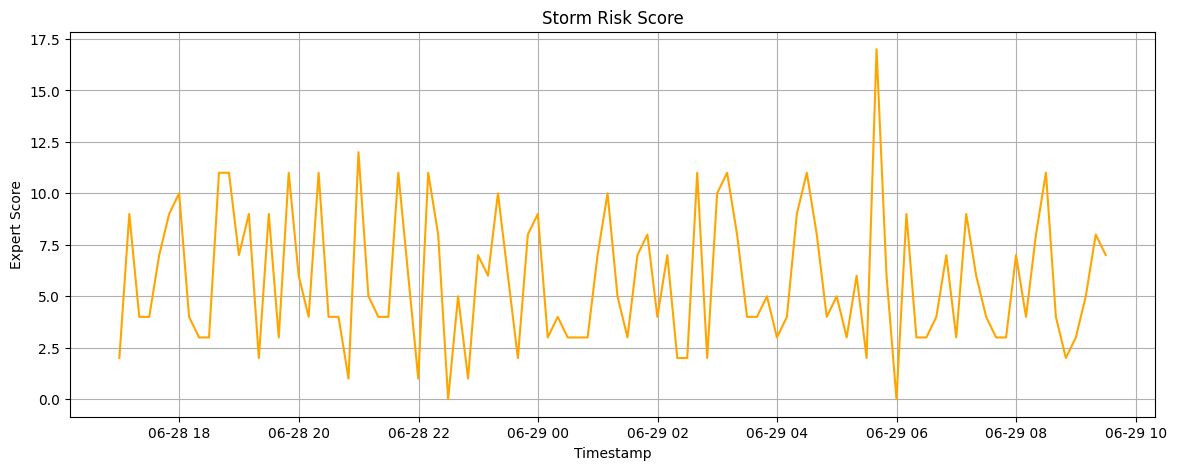

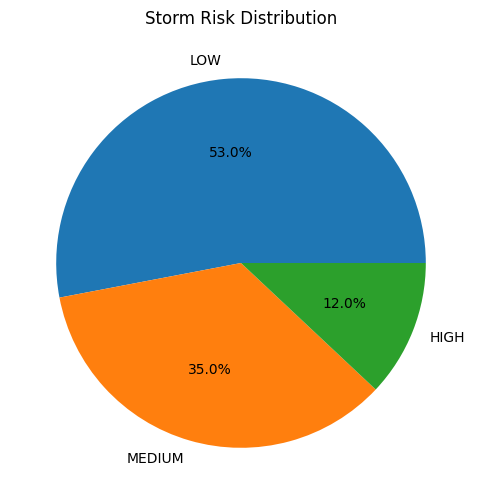

In [14]:
#Dashboard
plot_df = spark_df.orderBy("timestamp").toPandas()

plot_df.head()
#Preasure

plt.figure(figsize=(14,5))

plt.plot(
    plot_df["timestamp"],
    plot_df["pressure"],
    label="Pressure"
)

plt.title("Atmospheric Pressure Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Pressure (hPa)")
plt.grid(True)
plt.legend()
plt.savefig(
    "plots/pressure_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Preasure delta

plt.figure(figsize=(14,5))

plt.plot(
    plot_df["timestamp"],
    plot_df["pressure_delta"],
    color="red",
    label="Pressure Delta"
)

plt.axhline(-5, color="black", linestyle="--")

plt.title("Pressure Change")
plt.xlabel("Timestamp")
plt.ylabel("Pressure Delta")
plt.grid(True)
plt.legend()
plt.savefig(
    "plots/pressure_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Storm risk score

plt.figure(figsize=(14,5))

plt.plot(
    plot_df["timestamp"],
    plot_df["score"],
    color="orange"
)

plt.title("Storm Risk Score")
plt.xlabel("Timestamp")
plt.ylabel("Expert Score")
plt.grid(True)

plt.savefig(
    "plots/storm_risk_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Alert count

risk_counts = (
    plot_df["storm_risk"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%"
)

plt.title("Storm Risk Distribution")
plt.savefig(
    "plots/storm_risk_dist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()